In [1]:
import sys
from pathlib import Path

import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import pickle, arviz as az, seaborn as sns

# Robust paths (works even if notebook cwd is notebooks/)
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_PROCESSED_DIR, POSTERIORS_DIR, FIGURES_DIR, PROJECT_ROOT

# Load all results

df_test    = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_test.csv")
metrics_df = pd.read_csv(PROJECT_ROOT / "outputs" / "metrics_summary.csv")
cat_df     = pd.read_csv(PROJECT_ROOT / "outputs" / "per_category_metrics.csv")
cat_post   = pd.read_csv(PROJECT_ROOT / "outputs" / "per_category_posterior.csv")

trace_path = Path(POSTERIORS_DIR) / "hbrm_trace.nc"
if not trace_path.exists():
    raise FileNotFoundError(
        f"Missing trace file: {trace_path}. Run `notebooks/03_hbrm.ipynb` first."
    )
trace = az.from_netcdf(trace_path)

y_test = df_test["outcome"].values

pred_path = Path(POSTERIORS_DIR) / "all_predictions.pkl"
if not pred_path.exists():
    raise FileNotFoundError(
        f"Missing predictions file: {pred_path}. Run `notebooks/04_predictions.ipynb` first."
    )
with open(pred_path, "rb") as f:
    predictions = pickle.load(f)

categories = sorted(df_test["category_str"].unique().tolist())

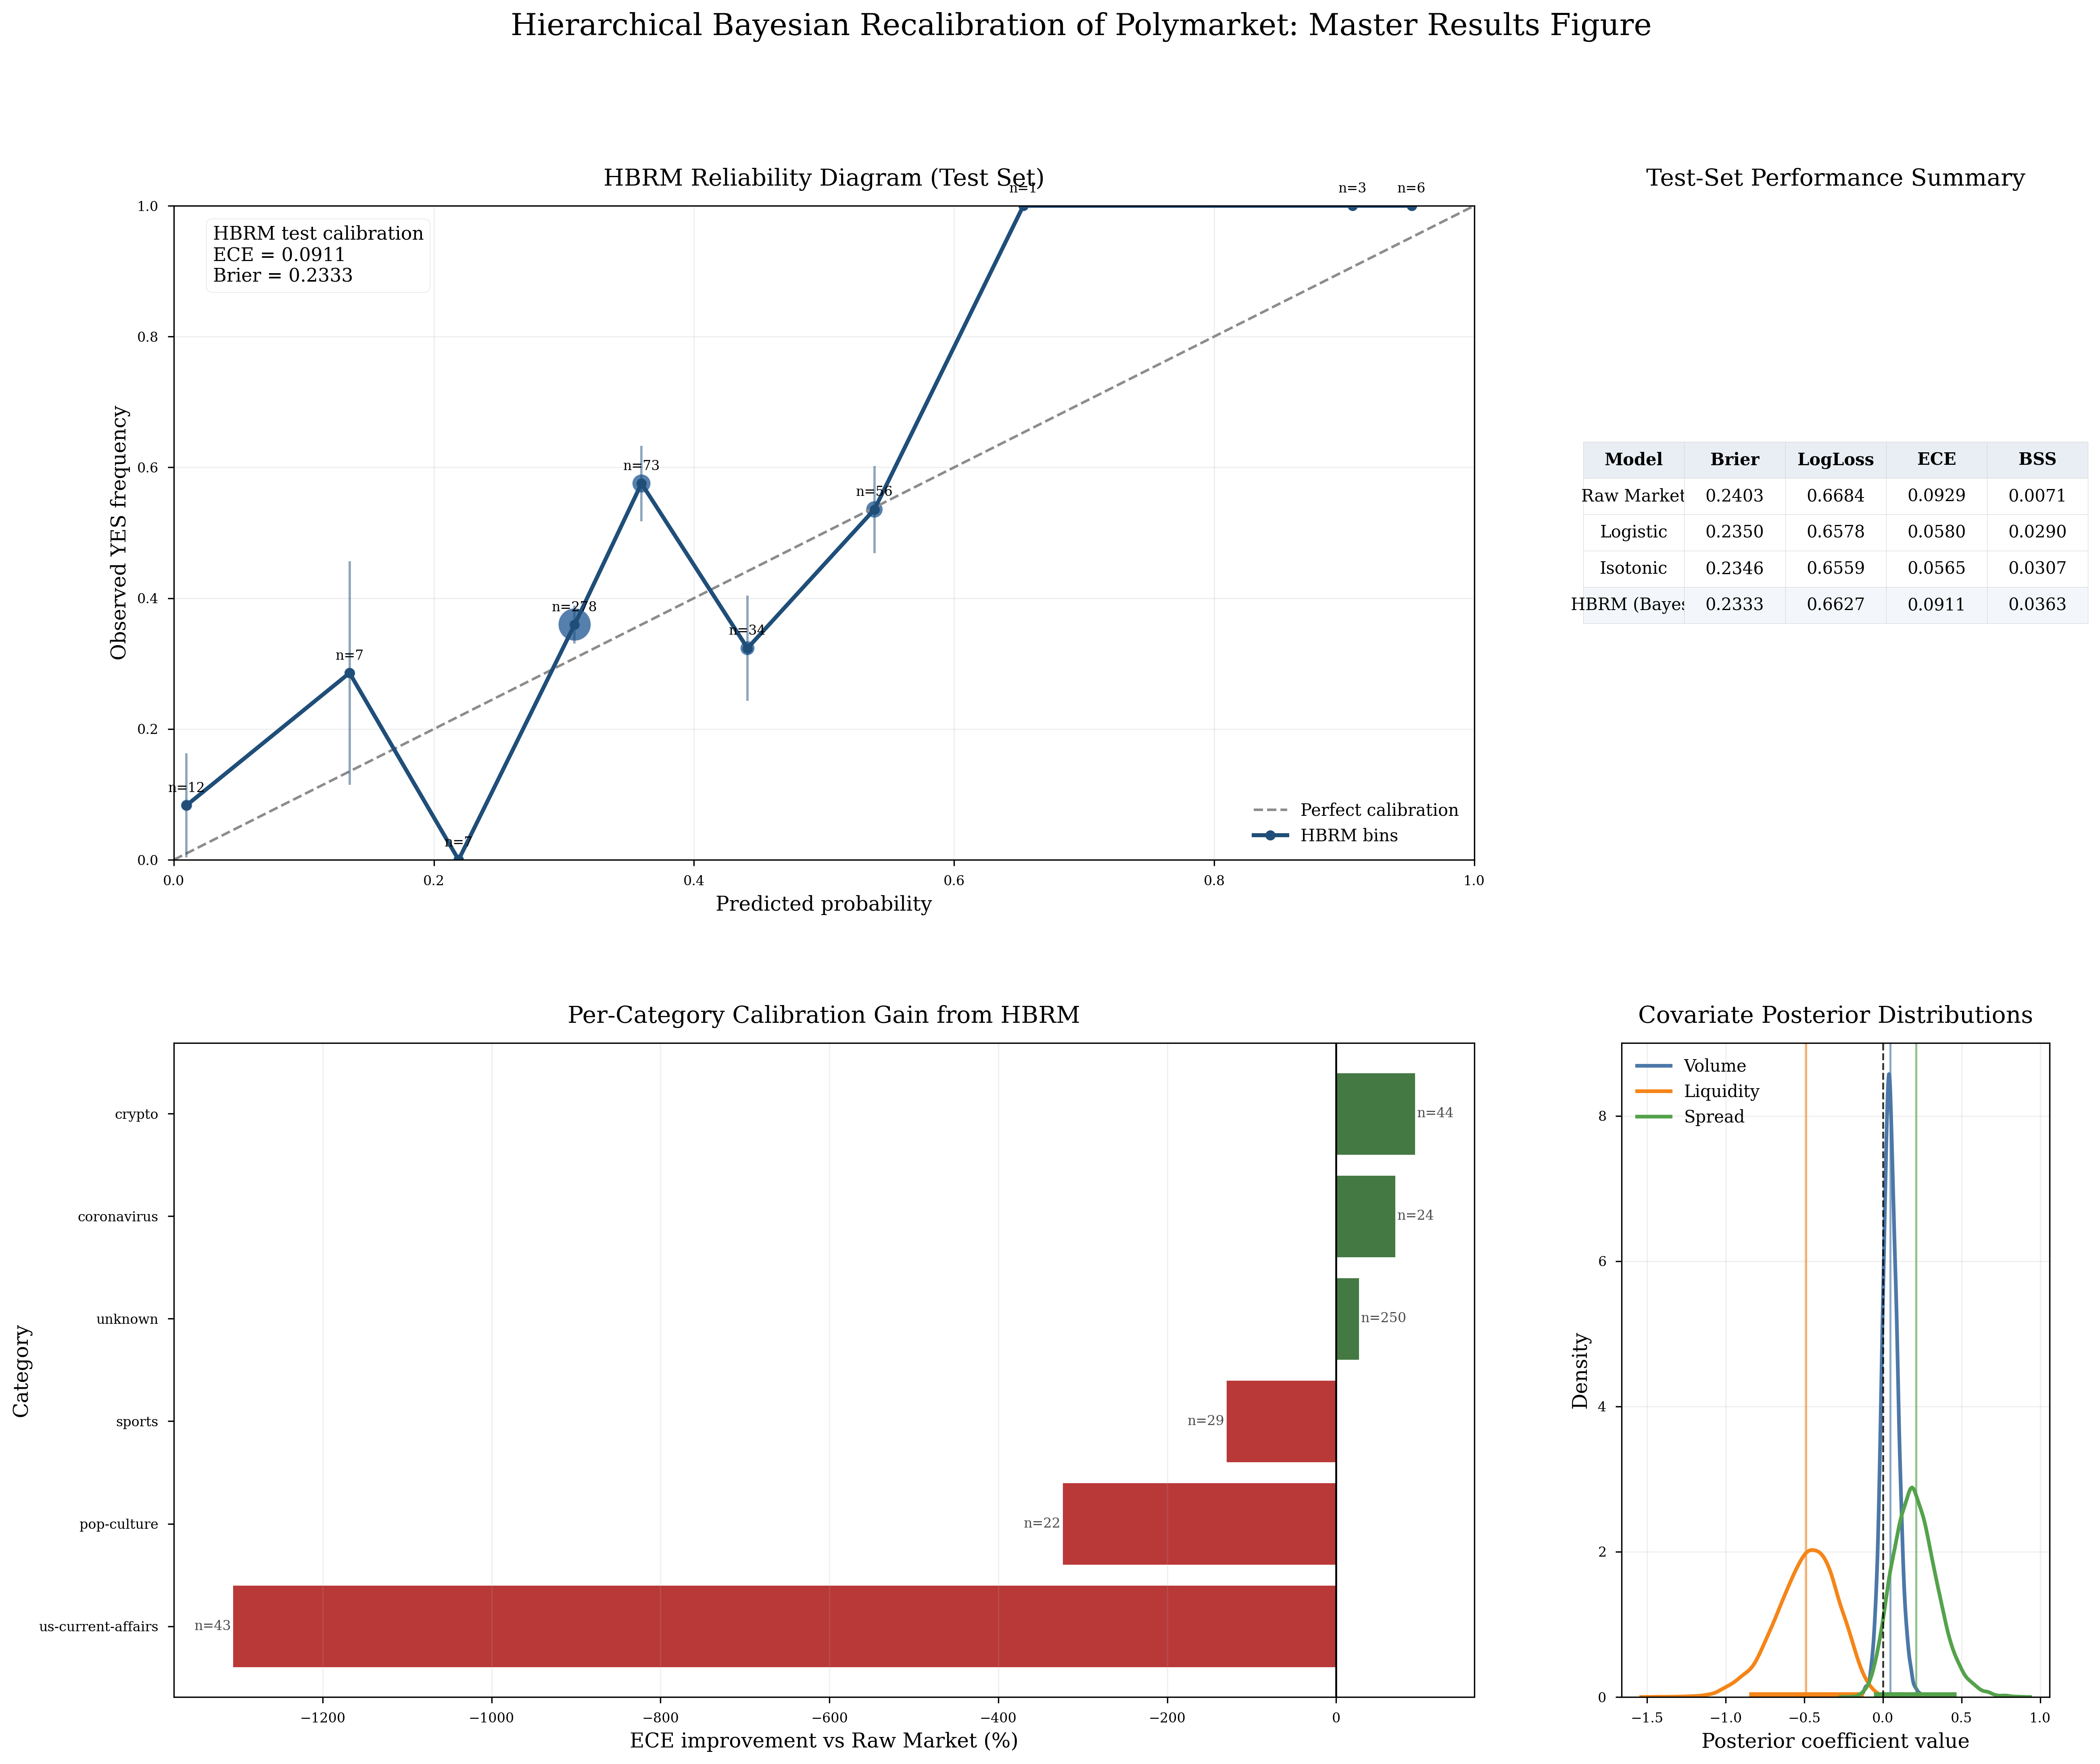

In [2]:
from pathlib import Path

plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
sns.set_palette('deep')
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

def reliability_bins(y_true, p_pred, n_bins=12):
    y = np.asarray(y_true, dtype=float)
    p = np.asarray(p_pred, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    accs = np.full(n_bins, np.nan)
    confs = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (p >= lo) & (p <= hi) if i == n_bins - 1 else (p >= lo) & (p < hi)
        counts[i] = int(mask.sum())
        if counts[i] > 0:
            accs[i] = y[mask].mean()
            confs[i] = p[mask].mean()
    valid = counts > 0
    return centers, accs, confs, counts, valid

fig = plt.figure(figsize=(20, 16), dpi=300)
gs = gridspec.GridSpec(
    2, 3, figure=fig,
    width_ratios=[1.55, 1.55, 1.15],
    height_ratios=[1.0, 1.0],
    wspace=0.28, hspace=0.28,
)

ax_rel = fig.add_subplot(gs[0, :2])
ax_tbl = fig.add_subplot(gs[0, 2])
ax_cat = fig.add_subplot(gs[1, :2])
ax_cov = fig.add_subplot(gs[1, 2])

hbrm_pred = np.asarray(predictions['HBRM (Bayes)'], dtype=float)
centers, accs, confs, counts, valid = reliability_bins(y_test, hbrm_pred, n_bins=12)
bin_sizes = 40 + 360 * (counts[valid] / counts[valid].max())
bin_error = np.sqrt(np.clip(accs[valid] * (1 - accs[valid]) / counts[valid], 0, None))

ax_rel.plot([0, 1], [0, 1], linestyle='--', color='0.55', linewidth=1.5, label='Perfect calibration')
ax_rel.plot(confs[valid], accs[valid], color='#1f4e79', linewidth=2.4, marker='o', markersize=6, label='HBRM bins')
ax_rel.errorbar(confs[valid], accs[valid], yerr=bin_error, fmt='none', ecolor='#1f4e79', alpha=0.5, capsize=3)
ax_rel.scatter(confs[valid], accs[valid], s=bin_sizes, color='#4c78a8', edgecolor='white', linewidth=0.9, alpha=0.95)
for x, y, n in zip(confs[valid], accs[valid], counts[valid]):
    ax_rel.annotate(f'n={n}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ece_hbrm = metrics_df.loc[metrics_df['Model'] == 'HBRM (Bayes)', 'ECE'].iloc[0]
brier_hbrm = metrics_df.loc[metrics_df['Model'] == 'HBRM (Bayes)', 'Brier Score'].iloc[0]
ax_rel.text(
    0.03, 0.97,
    f'HBRM test calibration\nECE = {ece_hbrm:.4f}\nBrier = {brier_hbrm:.4f}',
    transform=ax_rel.transAxes, va='top', ha='left', fontsize=11,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='0.85')
)
ax_rel.set_xlim(0, 1)
ax_rel.set_ylim(0, 1)
ax_rel.set_xlabel('Predicted probability', fontsize=12)
ax_rel.set_ylabel('Observed YES frequency', fontsize=12)
ax_rel.set_title('HBRM Reliability Diagram (Test Set)', fontsize=14, pad=12)
ax_rel.legend(frameon=False, loc='lower right', fontsize=10)
ax_rel.grid(alpha=0.18)

ax_tbl.axis('off')
metrics_display = metrics_df.copy()
metrics_display = metrics_display.set_index('Model').reindex(['Raw Market', 'Logistic', 'Isotonic', 'HBRM (Bayes)']).reset_index()
metrics_display['Brier Score'] = metrics_display['Brier Score'].map(lambda x: f'{x:.4f}')
metrics_display['Log Loss'] = metrics_display['Log Loss'].map(lambda x: f'{x:.4f}')
metrics_display['ECE'] = metrics_display['ECE'].map(lambda x: f'{x:.4f}')
metrics_display['Brier Skill Score'] = metrics_display['Brier Skill Score'].map(lambda x: f'{x:.4f}')
table = ax_tbl.table(
    cellText=metrics_display.values,
    colLabels=['Model', 'Brier', 'LogLoss', 'ECE', 'BSS'],
    cellLoc='center', colLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.18, 1.8)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('0.82')
    if r == 0:
        cell.set_facecolor('#e9eef4')
        cell.set_text_props(weight='bold')
    elif r == 4:
        cell.set_facecolor('#f3f7fb')
ax_tbl.set_title('Test-Set Performance Summary', fontsize=14, pad=12)

cat_plot = cat_df.sort_values('improvement_pct')
bar_colors = ['#b22222' if x < 0 else '#2f6b2f' for x in cat_plot['improvement_pct']]
ax_cat.barh(cat_plot['category'], cat_plot['improvement_pct'], color=bar_colors, alpha=0.9, edgecolor='white')
ax_cat.axvline(0, color='black', linewidth=1.1)
ax_cat.set_xlabel('ECE improvement vs Raw Market (%)', fontsize=12)
ax_cat.set_ylabel('Category', fontsize=12)
ax_cat.set_title('Per-Category Calibration Gain from HBRM', fontsize=14, pad=12)
ax_cat.grid(axis='x', alpha=0.18)
for i, (_, row) in enumerate(cat_plot.iterrows()):
    x = row['improvement_pct']
    ha = 'left' if x >= 0 else 'right'
    offset = 2 if x >= 0 else -2
    ax_cat.text(x + offset, i, f"n={int(row['n'])}", va='center', ha=ha, fontsize=8, color='0.3')

gamma_specs = [
    ('gamma_vol', 'Volume', '#4c78a8'),
    ('gamma_liq', 'Liquidity', '#f58518'),
    ('gamma_spr', 'Spread', '#54a24b'),
]
for var_name, label, color in gamma_specs:
    samples = np.asarray(trace.posterior[var_name]).reshape(-1)
    hdi = az.hdi(samples, hdi_prob=0.94)
    sns.kdeplot(samples, ax=ax_cov, color=color, linewidth=2.2, fill=False, label=label)
    ax_cov.axvline(samples.mean(), color=color, linewidth=1.2, alpha=0.65)
    ax_cov.plot([hdi[0], hdi[1]], [0.02, 0.02], color=color, linewidth=4, solid_capstyle='butt')
ax_cov.axvline(0, color='black', linestyle='--', linewidth=1.1, alpha=0.8)
ax_cov.set_xlabel('Posterior coefficient value', fontsize=12)
ax_cov.set_ylabel('Density', fontsize=12)
ax_cov.set_title('Covariate Posterior Distributions', fontsize=14, pad=12)
ax_cov.legend(frameon=False, fontsize=10)
ax_cov.grid(alpha=0.18)

fig.suptitle('Hierarchical Bayesian Recalibration of Polymarket: Master Results Figure', fontsize=18, y=0.98)
plt.savefig(Path(FIGURES_DIR) / 'MASTER_FIGURE.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
df_train = pd.read_csv('data/processed/markets_train.csv')
df_all = pd.concat([df_train, df_test], ignore_index=True)

date_candidates = ['created_at', 'end_date', 'createdAt', 'endDate', 'closedTime', 'updatedAt']
parsed_dates = []
for col in date_candidates:
    if col in df_all.columns:
        dt = pd.to_datetime(df_all[col], errors='coerce', utc=True)
        if dt.notna().any():
            parsed_dates.append(dt)

if parsed_dates:
    date_min = min(s.min() for s in parsed_dates if s.notna().any())
    date_max = max(s.max() for s in parsed_dates if s.notna().any())
    date_range_text = f"{date_min.date()} to {date_max.date()}"
else:
    date_range_text = 'Date range unavailable'

perf = metrics_df.set_index('Model').reindex(['Raw Market', 'Logistic', 'Isotonic', 'HBRM (Bayes)'])
best_brier_model = metrics_df.loc[metrics_df['Brier Score'].idxmin(), 'Model']
best_logloss_model = metrics_df.loc[metrics_df['Log Loss'].idxmin(), 'Model']
best_ece_model = metrics_df.loc[metrics_df['ECE'].idxmin(), 'Model']
best_bss_model = metrics_df.loc[metrics_df['Brier Skill Score'].idxmax(), 'Model']

ece_abs = (cat_df['raw_ece'] - cat_df['hbrm_ece']).abs()
most_shifted = cat_df.loc[ece_abs.nlargest(min(3, len(cat_df))).index, ['category', 'raw_ece', 'hbrm_ece', 'improvement_pct']]
most_overconf = cat_post.sort_values('prob_overconf', ascending=False).head(3)[['category', 'prob_overconf', 'beta_mean', 'alpha_mean']]

gamma_findings = []
significant_predictors = []
for var_name, label in [('gamma_vol', 'volume'), ('gamma_liq', 'liquidity'), ('gamma_spr', 'spread')]:
    samples = np.asarray(trace.posterior[var_name]).reshape(-1)
    hdi = az.hdi(samples, hdi_prob=0.94)
    is_sig = bool((hdi[0] > 0) or (hdi[1] < 0))
    direction = 'positive' if samples.mean() > 0 else 'negative'
    gamma_findings.append((label, samples.mean(), hdi[0], hdi[1], is_sig, direction))
    if is_sig:
        significant_predictors.append(f"{label} ({direction}, 94% HDI [{hdi[0]:.3f}, {hdi[1]:.3f}])")

summary_df = az.summary(trace, round_to=4)
rhat_col = 'r_hat' if 'r_hat' in summary_df.columns else 'rhat'
ess_candidates = [c for c in ['ess_bulk', 'ess_tail', 'ess_mean'] if c in summary_df.columns]
max_rhat = float(summary_df[rhat_col].max()) if rhat_col in summary_df.columns else np.nan
min_ess = float(summary_df[ess_candidates].min().min()) if ess_candidates else np.nan
if 'diverging' in trace.sample_stats:
    divergences = int(np.asarray(trace.sample_stats['diverging']).sum())
elif 'divergences' in trace.sample_stats:
    divergences = int(np.asarray(trace.sample_stats['divergences']).sum())
else:
    divergences = 0

conclusion = 'Sampler converged successfully' if (max_rhat <= 1.01 and min_ess >= 400 and divergences == 0) else 'Convergence issues detected'

raw_ece = perf.loc['Raw Market', 'ECE']
hbrm_ece = perf.loc['HBRM (Bayes)', 'ECE']
raw_brier = perf.loc['Raw Market', 'Brier Score']
hbrm_brier = perf.loc['HBRM (Bayes)', 'Brier Score']

if hbrm_brier < raw_brier and hbrm_ece < raw_ece:
    calibration_conclusion = 'HBRM improves both accuracy and calibration over the raw market baseline, indicating meaningful but heterogeneous miscalibration across categories.'
elif hbrm_brier < raw_brier:
    calibration_conclusion = 'HBRM improves probabilistic accuracy, but aggregate calibration remains mixed relative to the raw market baseline.'
elif hbrm_ece < raw_ece:
    calibration_conclusion = 'HBRM improves calibration error, though not overall probabilistic accuracy.'
else:
    calibration_conclusion = 'Aggregate metrics suggest limited overall improvement over the raw market baseline, with category-level gains and losses offsetting each other.'

print('=' * 60)
print('RESULTS SUMMARY: HIERARCHICAL BAYESIAN RECALIBRATION')
print('=' * 60)

print('\nSection 1: Dataset Statistics')
print(f'- Total resolved markets (train + test): {len(df_all)}')
print(f'- Number of categories: {len(categories)}')
print(f'- Overall YES resolution rate: {df_all["outcome"].mean():.4f}')
print(f'- Date range: {date_range_text}')

print('\nSection 2: Model Performance Table (formatted)')
print('| Model         | Brier  | LogLoss | ECE    | BSS    |')
print('|---------------|--------|---------|--------|--------|')
for model in ['Raw Market', 'Logistic', 'Isotonic', 'HBRM (Bayes)']:
    row = perf.loc[model]
    print(f"| {model:<13} | {row['Brier Score']:.4f} | {row['Log Loss']:.4f}  | {row['ECE']:.4f} | {row['Brier Skill Score']:.4f} |")

print('\nSection 3: Key Findings')
print(f'- Best Brier score: {best_brier_model}')
print(f'- Best log loss: {best_logloss_model}')
print(f'- Best ECE: {best_ece_model}')
print(f'- Best Brier Skill Score: {best_bss_model}')
print('- Categories with the largest category-level calibration shifts (absolute ECE change):')
for _, row in most_shifted.iterrows():
    print(f"  {row['category']}: raw ECE={row['raw_ece']:.4f}, HBRM ECE={row['hbrm_ece']:.4f}, improvement={row['improvement_pct']:.2f}%")
print('- Categories with the strongest posterior evidence of overconfidence:')
for _, row in most_overconf.iterrows():
    print(f"  {row['category']}: P(beta < 1)={row['prob_overconf']:.3f}, beta={row['beta_mean']:.3f}, alpha={row['alpha_mean']:+.3f}")
if significant_predictors:
    print(f"- Significant predictors: {', '.join(significant_predictors)}")
else:
    print('- Significant predictors: none at the 94% HDI threshold')
print(f'- Overall conclusion about Polymarket calibration quality: {calibration_conclusion}')

print('\nSection 4: MCMC Diagnostics')
print(f'- Max R-hat across all parameters: {max_rhat:.4f}')
print(f'- Min ESS: {min_ess:.1f}')
print(f'- Number of divergences: {divergences}')
print(f'- Conclusion: {conclusion}')

FileNotFoundError: [Errno 2] No such file or directory: 'data/processed/markets_train.csv'

In [ ]:
print('Figure inventory:')
print('outputs/figures/')
print('  00_raw_data_health.png            - Quality: raw data health overview (4 panels)')
print('  00_before_after_filtering.png     *** KEY FIGURE: before vs after filtering comparison')
print('  01_prob_distribution.png          - EDA: probability distribution (filtered data)')
print('  02_category_counts.png            - EDA: markets per category (filtered)')
print('  03_outcome_rate_by_category.png   - EDA: YES rate per category with CI')
print('  04_raw_calibration_check.png      - EDA: raw calibration diagnostic (filtered)')
print('  05_correlation_heatmap.png        - EDA: feature correlations')
print('  06_logistic_fit.png               - Baseline: logistic fit')
print('  07_isotonic_fit.png               - Baseline: isotonic fit')
print('  08_trace_global.png               - MCMC: trace plots')
print('  09_posterior_global.png           - MCMC: posterior distributions')
print('  10_forest_alpha_beta.png          - MCMC: per-category parameters')
print('  11_posterior_uncertainty.png      - Predictions: credible intervals')
print('  12_recalibration_shift.png        - Predictions: adjustment distribution')
print('  13_reliability_diagrams.png       *** MAIN FIGURE: calibration curves (all 4 models)')
print('  14_per_category_ece.png           *** MAIN FIGURE: category ECE comparison')
print('  15_brier_comparison.png           - Evaluation: Brier scores')
print('  16_covariate_posteriors.png       - Evaluation: gamma posteriors')
print('  17_category_alpha_beta_scatter.png *** MAIN FIGURE: alpha vs beta scatter per category')
print('  18_overconfidence_probability.png  - Interpretation: P(overconfident) per category')
print('  MASTER_FIGURE.png                 *** PAPER FIGURE: combined layout')
print('\nFigures marked *** are the primary ones for presentation slides and the IEEE paper.')
print('\nAlso remember the quality report outputs:')
print('outputs/quality_report/')
print('  filter_log.csv          - the filtering table (use this in the IEEE paper Data section)')
print('  category_counts.csv     - per-category market counts after filtering')